# Testing Model Robustness
now abandoned as in fact the robustness cannot be really tested:
- UMAP is stochastic
- findEmbeddings() depends on supplied data to compute wavelet power and transform

## Imports

In [18]:
import glob, hdf5storage, h5py, pickle
from IPython.display import Image
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import motionmapperpy as mmpy
from time import time

## Configuration

In [2]:
projectPath = r"/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/WideNormalisation"
region_id = 8

## Main code

In [3]:
parameters = pickle.load(open(f"{projectPath}/parameters.pkl", "rb"))

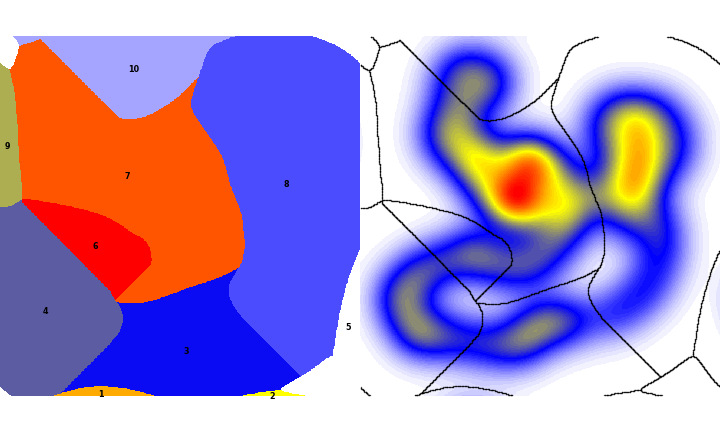

In [4]:

# First show the image of the UMAP density plot
Image(glob.glob(f'{projectPath}/{parameters.method}/zWshed*.png')[0])

## Extract of real data
Here we should not tolerate any missclassification

In [21]:
# Compute barycenters
if parameters.method == 'TSNE':
    zValstr = 'zVals'
else:
    zValstr = 'uVals'

ally = hdf5storage.loadmat(glob.glob(parameters.projectPath+f'/Projections/*_{zValstr}.mat')[0])['zValues']
rounded_ally = np.round(ally, decimals=2)

# wregs : 1D array containing the region label for each point (0 = background, 1..K = regions)
wshedfile = hdf5storage.loadmat(f'{projectPath}/{parameters.method}/zVals_wShed_groups.mat')
wregs = wshedfile['watershedRegions'].flatten().astype(int)


assert len(rounded_ally) == len(wregs)

region_ids = np.unique(wregs)

barycenters = {}  # dict: region_id -> (x_mean, y_mean)

for rid in region_ids:
    if rid == 0:
        # Ignore region 0 if it is the backgound
        continue
    
    mask = (wregs == rid)
    if not np.any(mask):
        continue 

    pts = rounded_ally[mask]      # shape (n_points_region, 2)
    center = pts.mean(axis=0)     # shape (2,)

    barycenters[int(rid)] = (float(center[0]), float(center[1]))

print(barycenters)


{3: (-4.288032054901123, -58.299625396728516), 4: (-58.89750671386719, -46.40108871459961), 6: (-32.234405517578125, -20.816862106323242), 7: (-12.486595153808594, 15.787028312683105), 8: (49.32156753540039, 15.856051445007324), 10: (-31.83527946472168, 67.92164611816406)}


In [23]:
# Find a succession of 12h of data that was classified in the given region_id.

# 1) Identify all points classified in the target region
projectionFiles = glob.glob(projectPath+'/Projections/*pcaModes.mat')
projections = hdf5storage.loadmat(projectionFiles[0])['projections']
region_mask = (wregs == region_id)
region_indices = np.where(region_mask)[0]

print(f"Found {len(region_indices)} points classified in region {region_id}")

# 2) Try to find a consecutive 12h block (72 points at 10-min sampling)
n_points_12h = 72
found = False
projections_real_12h = None

for i in range(len(region_indices) - n_points_12h + 1):
    # Check if these indices form a consecutive sequence
    block = region_indices[i:i+n_points_12h]
    if np.array_equal(block, np.arange(block[0], block[-1]+1)):
        # Found consecutive indices all in this region
        projections_real_12h = projections[block].copy()
        found = True
        print(f"\n✓ Found consecutive 12h block purely in region {region_id}")
        break

if not found and len(region_indices) >= n_points_12h:
    raise ValueError(f"Could not find a consecutive 12h block purely in region {region_id}, but there are at least {n_points_12h} points classified in this region. Consider using the first {n_points_12h} points instead.")

if projections_real_12h is not None:
    print(f"Shape: {projections_real_12h.shape}")
    if found:
        print(f"Region classifications: all {region_id}")
    else:
        print(f"Region classifications: {np.unique(wregs[region_indices[:n_points_12h]])}")
else:
    print(f"ERROR: Could not extract 12h block for region {region_id}")


Found 3514 points classified in region 8

✓ Found consecutive 12h block purely in region 8
Shape: (72, 4)
Region classifications: all 8


### UMAP process the real data

In [24]:
# Embed real data using trained UMAP model
tfolder = projectPath + f'/{parameters.method}/'

# Load training data + training embedding
with h5py.File(tfolder + 'training_data.mat', 'r') as hfile:
    trainingSetData = hfile['trainingSetData'][:].T

with h5py.File(tfolder + 'training_embedding.mat', 'r') as hfile:
    trainingEmbedding = hfile['trainingEmbedding'][:].T

# Find embeddings using trained UMAP
print("Finding UMAP embeddings for real data...")
t_start = time()
zValues_real, outputStatistics_real = mmpy.findEmbeddings(
    projections_real_12h,
    trainingSetData,
    trainingEmbedding,
    parameters
)
t_elapsed = time() - t_start

print(f"✓ UMAP embedding completed in {t_elapsed:.2f} seconds")
print(f"  Real data embedding shape: {zValues_real.shape}")

# Store for later use
ally_real = zValues_real

Finding UMAP embeddings for real data...
Finding Wavelets
	 Calculating wavelets, clock starting.
	 Using #12 CPUs.
	 Done at 0.26 seconds.
Finding Embeddings
	Loading UMAP Model.
	Loaded.
Embeddings found in 0.83 seconds.
✓ UMAP embedding completed in 1.09 seconds
  Real data embedding shape: (72, 2)


### Plotting

Extracted 4080 watershed border points in UMAP space


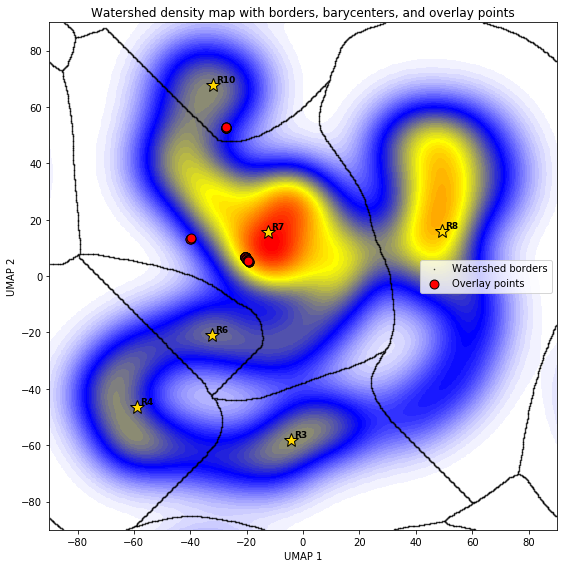

In [25]:
# Extract and plot watershed borders on top of the watershed density map
points_used = np.asarray(ally_real)

# Load the watershed result file, which contains the watershed density, axis, and borders
wshed_path = f'{projectPath}/{parameters.method}/zVals_wShed_groups.mat'
wshedfile = hdf5storage.loadmat(wshed_path)

# Use the saved watershed density map (right panel of zWshed*.png)
density_map = np.asarray(wshedfile['density']).squeeze()
xx = np.asarray(wshedfile['xx']).squeeze().ravel()

# Border coordinates are stored as (x_coords, y_coords)
wbounds = np.asarray(wshedfile['wbounds']).squeeze()

# Normalize to a simple Nx2 array for later reuse
if wbounds.dtype == object:
    wbounds_list = [np.asarray(item).ravel() for item in wbounds.tolist()]
    wbounds_x, wbounds_y = wbounds_list[0], wbounds_list[1]
elif wbounds.ndim == 2 and wbounds.shape[0] == 2:
    wbounds_x, wbounds_y = wbounds[0].ravel(), wbounds[1].ravel()
elif wbounds.ndim == 2 and wbounds.shape[1] == 2:
    wbounds_x, wbounds_y = wbounds[:, 0].ravel(), wbounds[:, 1].ravel()
else:
    raise ValueError(f'Unexpected wbounds shape: {wbounds.shape}')

# Convert watershed border coordinates from density-grid pixel space to UMAP space.
# wbounds are produced from the watershed raster, so they need to be mapped onto the
# same coordinate axis used by the density plot / UMAP embedding.
grid_x = np.arange(len(xx))
grid_y = np.arange(len(xx))

border_umap_x = np.interp(wbounds_x, grid_x, xx)
border_umap_y = np.interp(wbounds_y, grid_y, xx)
watershed_border_xy = np.column_stack((border_umap_x, border_umap_y))
print(f'Extracted {len(watershed_border_xy)} watershed border points in UMAP space')

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(density_map, cmap=mmpy.gencmap(), extent=(xx[0], xx[-1], xx[0], xx[-1]), origin='lower')

# Plot the watershed borders on top of the density map
ax.scatter(
    watershed_border_xy[:, 0],
    watershed_border_xy[:, 1],
    s=0.25,
    c='black',
    alpha=0.8,
    label='Watershed borders'
)

labels_used = None
if 'overlay_labels' in globals():
    labels_used = np.asarray(overlay_labels)

if len(points_used):
    if labels_used is not None and len(labels_used) == len(points_used):
        cmap = plt.cm.tab20
        sc = ax.scatter(points_used[:, 0], points_used[:, 1], c=labels_used, cmap=cmap, s=80, edgecolors='k')
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label('Label')
    else:
        ax.scatter(points_used[:, 0], points_used[:, 1], c='red', s=80, edgecolors='k', label='Overlay points')

# Plot barycenters on top of everything
if 'barycenters' in globals():
    for rid, (bx, by) in barycenters.items():
        ax.plot(bx, by, marker='*', color='gold', markersize=14, markeredgecolor='black', markeredgewidth=1.0)
        ax.text(bx + 1, by + 1, f'R{rid}', fontsize=9, fontweight='bold', color='black')

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Watershed density map with borders, barycenters, and overlay points')
ax.legend(loc='best')
plt.tight_layout()
plt.show()